# 04 - Interpretability and sparse equations

This notebook turns the trained SINDy model into paper-ready interpretability artifacts: coefficient tables, heatmaps, top terms and sign checks for physically expected effects.

In [1]:
from pathlib import Path
import sys

HERE = Path.cwd().resolve()
if (HERE / 'article_experiment_utils.py').exists():
    ARTICLE_DIR = HERE
    REPO_DIR = HERE.parent
else:
    ARTICLE_DIR = HERE / 'own-article'
    REPO_DIR = HERE
sys.path.insert(0, str(ARTICLE_DIR))
sys.path.insert(0, str(REPO_DIR))

from article_experiment_utils import *
OUT = results_dir()

In [2]:
FAST_MODE = False
candidate_paths = [
    OUT / 'models' / ('dagger_iter_1_fast.pkl' if FAST_MODE else 'dagger_iter_3.pkl'),
    OUT / 'models' / ('physics_sindy_mpc_fast.pkl' if FAST_MODE else 'physics_sindy_mpc.pkl'),
    OUT / 'models' / ('physics_full_7d.pkl' if FAST_MODE else 'physics_full_60d.pkl'),
]

bundle = None
for path in candidate_paths:
    if path.exists():
        bundle = load_bundle(path)
        print(f'Loaded {path.name}')
        break

if bundle is None:
    cfg = ExperimentConfig(n_days=7 if FAST_MODE else 60, start_date='2010-02-28')
    train_path = OUT / 'datasets' / ('rbc_train_fast.npz' if FAST_MODE else 'rbc_train_60d.npz')
    train_data = load_dataset(train_path) if train_path.exists() else collect_rule_based_dataset(cfg)
    bundle = fit_sindy(train_data, feature_variant='physics', library_degree=1, period=float(cfg.period), metadata={'label': 'physics_full'})
    save_bundle(bundle, OUT / 'models' / ('physics_full_interpretability_fast.pkl' if FAST_MODE else 'physics_full_interpretability.pkl'))

bundle.feature_variant, bundle.train_rows, bundle.condition_number

C:\Users\zergu\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\Lib\site-packages\pysindy\__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound


Loaded dagger_iter_3.pkl


('physics', 7199, 71.42717390587984)

In [3]:
coefs = coefficient_table(bundle)
nonzero = coefs[coefs['nonzero']].sort_values(['equation', 'abs_coefficient'], ascending=[True, False])
sign_checks = sign_check_table(bundle)

save_table(coefs, OUT / 'tables' / ('sindy_coefficients_fast.csv' if FAST_MODE else 'sindy_coefficients.csv'))
save_table(nonzero, OUT / 'tables' / ('sindy_nonzero_coefficients_fast.csv' if FAST_MODE else 'sindy_nonzero_coefficients.csv'))
save_table(sign_checks, OUT / 'tables' / ('sindy_physical_sign_checks_fast.csv' if FAST_MODE else 'sindy_physical_sign_checks.csv'))

nonzero.groupby('equation').head(12)

,equation,term,coefficient,abs_coefficient,nonzero
34,co2,uVent,-1.833850,1.833850,True
41,co2,h_uVent,1.681679,1.681679,True
23,co2,t_in,-0.948524,0.948524,True
24,co2,co2,0.885413,0.885413,True
32,co2,uCO2,0.697239,0.697239,True
37,co2,psat,0.677612,0.677612,True
38,co2,vpd,0.645257,0.645257,True
40,co2,t_S_eff,-0.589717,0.589717,True
39,co2,S_eff,0.395582,0.395582,True
25,co2,rh,0.378480,0.378480,True


,equation,term,expected_sign,coefficient,verdict,interpretation
0,co2,dc_uVent,negative,-0.370994,consistent,ventilation should reduce indoor CO2 gradient
1,rh,h_uVent,negative,1.774219,opposite,ventilation should reduce humidity
2,t_in,t_uBoil,positive,0.151816,consistent,heating should increase or maintain temperature
3,t_in,S_eff,positive,1.841565,consistent,solar gain should increase or maintain tempera...


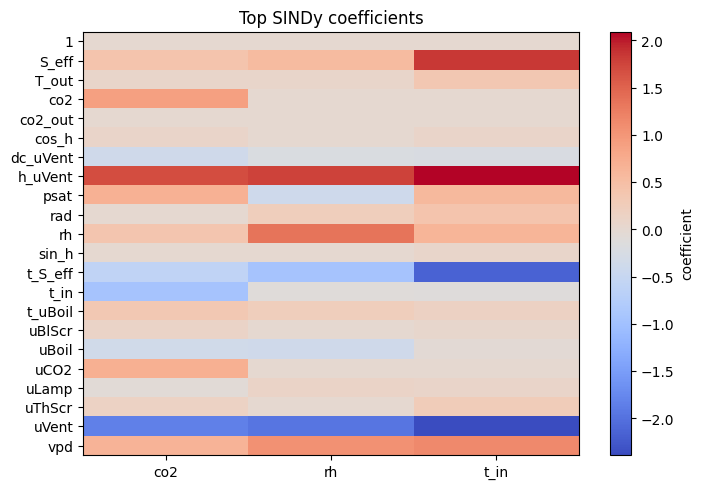

In [4]:
plot_coefficient_heatmap(bundle, OUT / 'figures', top_n=30)
sign_checks

In [5]:
def equation_text(nonzero_df, state, top_n=12):
    terms = nonzero_df[nonzero_df['equation'].eq(state)].head(top_n)
    parts = []
    for _, row in terms.iterrows():
        coef = row['coefficient']
        sign = '+' if coef >= 0 else '-'
        parts.append(f' {sign} {abs(coef):.4g}*{row["term"]}')
    return f'{state}_next_scaled =' + ''.join(parts)

equations = pd.DataFrame({
    'equation': STATE_NAMES,
    'text': [equation_text(nonzero, s) for s in STATE_NAMES],
})
save_table(equations, OUT / 'tables' / ('sindy_equations_text_fast.csv' if FAST_MODE else 'sindy_equations_text.csv'))
for text in equations['text']:
    print(text)
    print()

t_in_next_scaled = - 2.389*uVent - 2.144*t_S_eff + 2.092*h_uVent + 1.842*S_eff + 1.135*vpd + 0.6289*rh + 0.579*psat + 0.3955*rad + 0.3578*T_out + 0.2563*uThScr - 0.2254*dc_uVent + 0.1518*t_uBoil

co2_next_scaled = - 1.834*uVent + 1.682*h_uVent - 0.9485*t_in + 0.8854*co2 + 0.6972*uCO2 + 0.6776*psat + 0.6453*vpd - 0.5897*t_S_eff + 0.3956*S_eff + 0.3785*rh - 0.371*dc_uVent - 0.3532*uBoil

rh_next_scaled = - 1.953*uVent + 1.774*h_uVent + 1.349*rh + 1.052*vpd - 0.9518*t_S_eff + 0.5473*S_eff - 0.3896*psat - 0.3621*uBoil + 0.2278*t_uBoil + 0.2213*rad - 0.2088*dc_uVent - 0.1044*t_in

